#### Набиваем шишки

Пусть у нас есть юридическое лицо $i$ и момент времени $t$. Целевая величина $Y_{it}$ -- оборот юридического лица в месяц $t$ может быть декомпозирована следующим образом:

$$
Y_{it} = A_{it} \cdot S_{it},
$$

где:

- $A_{it} \in \{0,1\}$ -- активность юридического лица, то есть факт ненулевого оборота
- $S_{it} > 0$ -- собственно оборот при условии активности.

Кажется самым логичным подходом предсказывать нашу величину как произведение двух моделей:

$$
\hat{Y}_{it} = \hat{P}(A_{it} = 1 | X_{it}) \cdot \hat{E}(S_{it}|A_{it} = 1, X_{it}),
$$

давайте попробуем реализовать подобный подход на "учебной" задаче:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit  # sigmoid
from scipy.stats import norm

from tqdm import tqdm
from sklearn.linear_model import LogisticRegression, LinearRegression

from py_functions.data_generation import *

#### Реализуем функцию, генерирующую случайный датасет:

пусть в итоговом датасете будет:

- флаг активности ***activity***
- положительный оборот ***gmv***
- предсказания моделей ***activity_pred*** и ***gmv_act_pred***

и пусть ошибки модели будут коррелированными с коэффициентом корреляции ***correlation_coefficient***

In [171]:
def generate_norm_dist(size, x=0, y=1):
    return sps.norm.rvs(x, y, size=size)

def generate_correlating_distributions(size, correlation_coefficient):
    d1 = generate_norm_dist(size)
    d1 -= d1.mean()
    d2_ind = generate_norm_dist(size)
    d2 = correlation_coefficient * d1 + np.sqrt(1 - correlation_coefficient**2) * d2_ind
    d2 -= d2.mean()
    return(d1, d2)

def generate_sample_dataset(size, correlation_coefficient):

    d1, d2 = generate_correlating_distributions(size, correlation_coefficient)
    
    act_proba = generate_norm_dist(size, 0.5, 0.2).clip(0.01,0.99)
    act_fact = sps.bernoulli.rvs(act_proba)
    gmv = generate_norm_dist(size, 10, 4)

    # накидываем шум на финальные "предсказания" моделей, иначе эффекты нелинейности съедают нужный эффект на синтетике :(
    act_pred = (act_proba + d1/10).clip(0.01,0.99)
    gmv_act_pred = gmv + 3 * d2
    gmv_pred = gmv_act_pred * act_pred

    df = pd.DataFrame(
        {
            'index':np.arange(size),
            'active_flg':act_fact,
            'gmv':act_fact * gmv,
            'act_pred':act_pred,
            'gmv_act_pred':gmv_act_pred,
            'gmv_pred':gmv_pred
        }
    )

    return df    

In [172]:
def calc_relative_error(df, f1, f2):
    relative_error = (df[f1] - df[f2]).mean()/df[f1].mean()
    return relative_error

def calc_rel_errors_(corr_coef, size=10000):

    df = generate_sample_dataset(size,corr_coef)
    df_act = df[df.active_flg == 1]
    act_error = calc_relative_error(df, 'active_flg', 'act_pred')
    gmv_act_error = calc_relative_error(df_act, 'gmv', 'gmv_act_pred')
    gmv_error = calc_relative_error(df, 'gmv', 'gmv_pred')

    return act_error, gmv_act_error, gmv_error

def calc_rel_errors(corr_coef, size=10000):

    print('Коэффициент корреляции ошибок:', corr_coef)

    act_error, gmv_act_error, gmv_error = calc_rel_errors_(corr_coef, size)

    print(f'Activity relative error: {round(act_error * 100,2)} %')
    print(f'GMV active relative error: {round(gmv_act_error * 100,2)} %')
    print(f'GMV relative error: {round(gmv_error * 100,2)} %')

In [173]:
calc_rel_errors(0)

Коэффициент корреляции ошибок: 0
Activity relative error: 0.59 %
GMV active relative error: 0.31 %
GMV relative error: 0.25 %


In [174]:
calc_rel_errors(0.5)

Коэффициент корреляции ошибок: 0.5
Activity relative error: -0.43 %
GMV active relative error: 0.14 %
GMV relative error: -3.45 %


In [175]:
calc_rel_errors(1)

Коэффициент корреляции ошибок: 1
Activity relative error: 0.57 %
GMV active relative error: 0.26 %
GMV relative error: -5.32 %


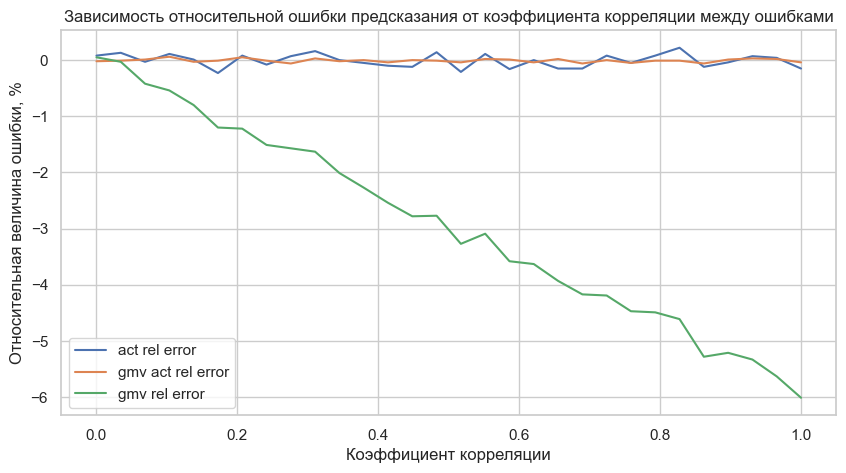

In [176]:
corrs_grid = np.linspace(0,1,30)
errors = np.zeros((3,30))

for ix, corr in enumerate(corrs_grid):
    
    errors_ = np.zeros((3,100))
    for i in range(100):
        errors_[0][i], errors_[1][i], errors_[2][i] = calc_rel_errors_(corr)
    errors[0][ix] = round(errors_[0].mean() * 100, 2)
    errors[1][ix] = round(errors_[1].mean() * 100, 2)
    errors[2][ix] = round(errors_[2].mean() * 100, 2)

plt.figure(figsize = (10,5))

plt.title('Зависимость относительной ошибки предсказания от коэффициента корреляции между ошибками')

plt.plot(corrs_grid, errors[0], label = 'act rel error')
plt.plot(corrs_grid, errors[1], label = 'gmv act rel error')
plt.plot(corrs_grid, errors[2], label = 'gmv rel error')

plt.legend()

plt.xlabel('Коэффициент корреляции')
plt.ylabel('Относительная величина ошибки, %')

plt.show()